<a href="https://colab.research.google.com/github/salianvikram/Predictive-Indoor-Outdoor-Air-Quality-Control-System/blob/main/GB_PM2_5%2CPM10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully.

Dataset loaded successfully.
Dataset shape: (1048575, 4)

Dataset columns:
['Datetime', 'PM2.5', 'PM10', 'AQI']

First 5 rows:
           Datetime  PM2.5    PM10  AQI
0  24-11-2017 17:00  60.50   98.00  NaN
1  24-11-2017 18:00  65.50  111.25  NaN
2  24-11-2017 19:00  80.00  132.00  NaN
3  24-11-2017 20:00  81.50  133.25  NaN
4  24-11-2017 21:00  75.25  116.00  NaN

All required columns are available.

Datetime conversion completed.

Numeric conversion completed.

Dataset sorted chronologically.

Time features created.

Cyclic time features created.

PM2.5 lag features created.

PM10 lag features created.

AQI lag features created.

PM2.5 rolling features created.

PM10 rolling features created.

AQI rolling features created.

Next-hour AQI target created.

Total number of features: 39

Rows after removing missing values: 1006


TRAIN / TEST SPLIT
Training rows: 644
Testing rows: 362

X_train: (644, 39)
X_test: (362, 39)


TRAINING GRADIENT BOOSTING MOD

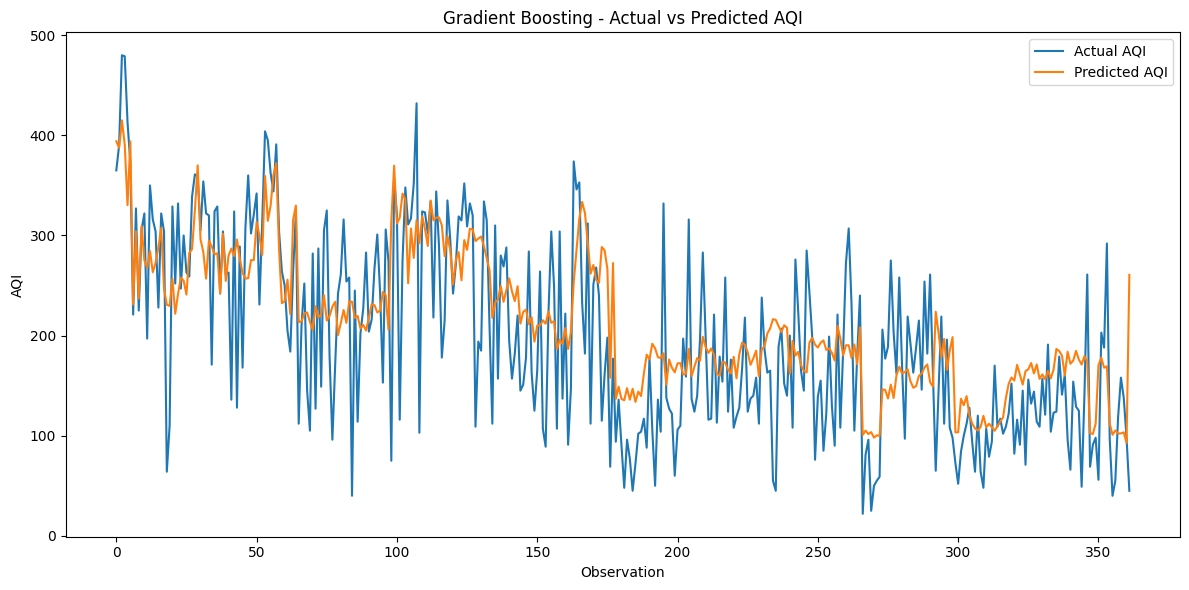

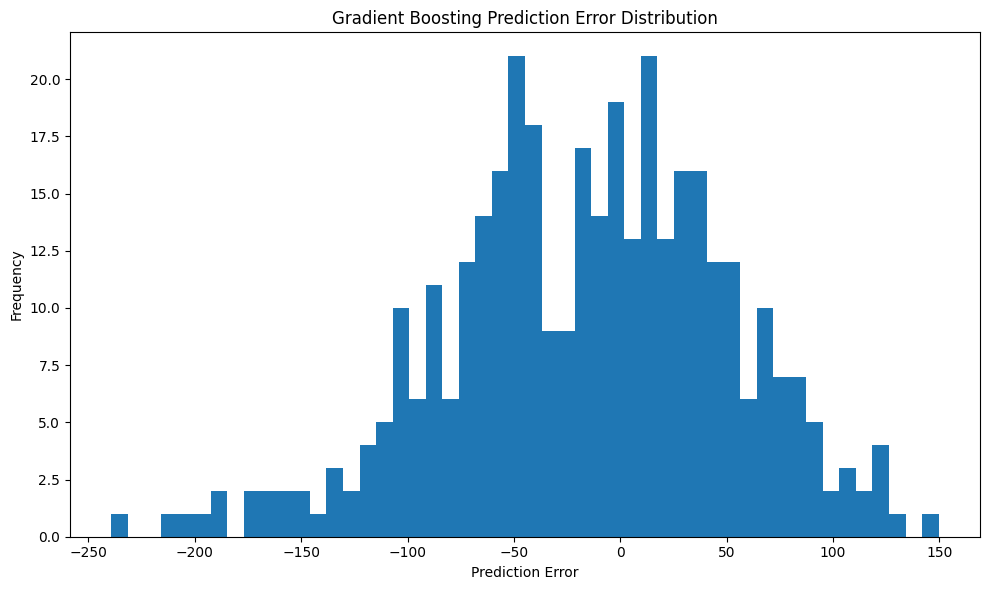

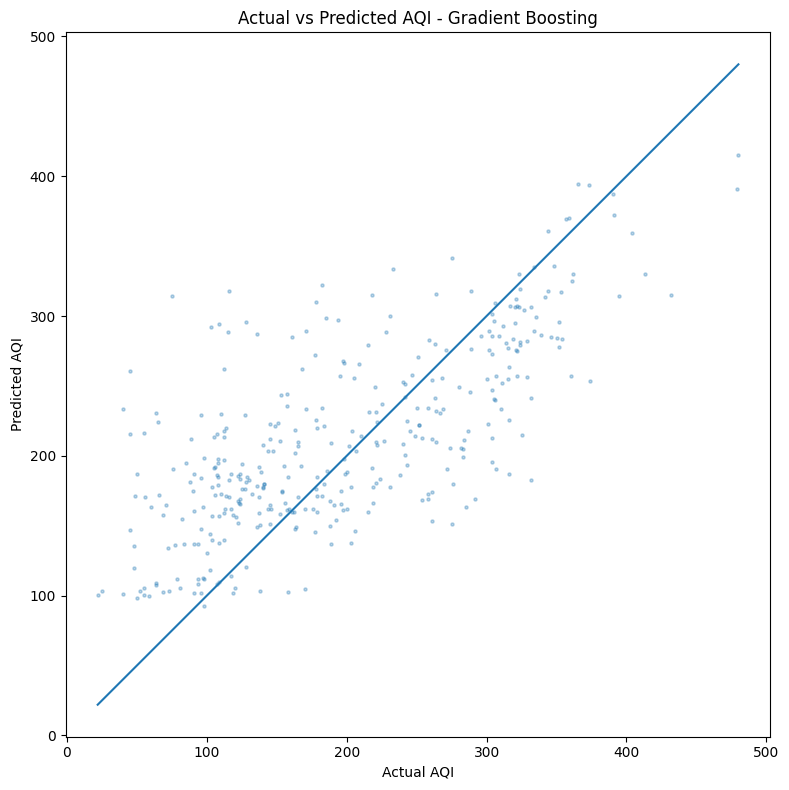


Model saved successfully:
AQI_GradientBoosting_PM_Model.pkl

Feature list saved successfully.


SAMPLE PREDICTIONS
    Actual_AQI  Predicted_AQI  Absolute_Error
0        365.0         394.09           29.09
1        390.0         387.53            2.47
2        480.0         415.01           64.99
3        479.0         390.90           88.10
4        413.0         330.25           82.75
5        373.0         394.00           21.00
6        221.0         231.00           10.00
7        327.0         304.22           22.78
8        225.0         237.05           12.05
9        306.0         309.44            3.44
10       322.0         275.27           46.73
11       197.0         267.61           70.61
12       350.0         284.49           65.51
13       316.0         263.29           52.71
14       304.0         272.60           31.40
15       228.0         288.26           60.26
16       322.0         307.52           14.48
17       304.0         247.06           56.94
18        

In [1]:
# ============================================================
# AQI PREDICTION USING GRADIENT BOOSTING
#
# DATASET:
# station_hour_pm_aqi.csv
#
# AVAILABLE COLUMNS:
# Datetime
# PM2.5
# PM10
# AQI
#
# MODEL:
# Histogram Gradient Boosting
#
# TARGET:
# NEXT-HOUR AQI
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")


# ============================================================
# 2. LOAD DATASET
# ============================================================

FILE_NAME = "station_hour_pm_aqi.csv"

df = pd.read_csv(FILE_NAME)

print("\nDataset loaded successfully.")

print("Dataset shape:", df.shape)


# ============================================================
# 3. DISPLAY DATASET INFORMATION
# ============================================================

print("\nDataset columns:")

print(
    df.columns.tolist()
)

print("\nFirst 5 rows:")

print(
    df.head()
)


# ============================================================
# 4. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
)


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [

    'Datetime',
    'PM2.5',
    'PM10',
    'AQI'

]


missing_columns = [

    col

    for col in required_columns

    if col not in df.columns

]


if len(missing_columns) > 0:

    raise ValueError(

        "Missing required columns: "
        + str(missing_columns)

    )


print(
    "\nAll required columns are available."
)


# ============================================================
# 6. CONVERT DATETIME
# ============================================================

df['Datetime'] = pd.to_datetime(

    df['Datetime'],

    format='%d-%m-%Y %H:%M',

    errors='coerce'

)


# Remove invalid dates

df = df.dropna(

    subset=['Datetime']

)


print(
    "\nDatetime conversion completed."
)


# ============================================================
# 7. CONVERT NUMERIC COLUMNS
# ============================================================

numeric_columns = [

    'PM2.5',
    'PM10',
    'AQI'

]


for col in numeric_columns:

    df[col] = pd.to_numeric(

        df[col],

        errors='coerce'

    )


print(
    "\nNumeric conversion completed."
)


# ============================================================
# 8. SORT DATA CHRONOLOGICALLY
# ============================================================

df = df.sort_values(

    by='Datetime'

).reset_index(

    drop=True

)


print(
    "\nDataset sorted chronologically."
)


# ============================================================
# 9. CREATE TIME FEATURES
# ============================================================

df['Hour'] = (

    df['Datetime']
    .dt.hour

)


df['Day'] = (

    df['Datetime']
    .dt.day

)


df['Month'] = (

    df['Datetime']
    .dt.month

)


df['DayOfWeek'] = (

    df['Datetime']
    .dt.dayofweek

)


df['DayOfYear'] = (

    df['Datetime']
    .dt.dayofyear

)


df['Year'] = (

    df['Datetime']
    .dt.year

)


df['IsWeekend'] = (

    df['DayOfWeek'] >= 5

).astype(int)


print(
    "\nTime features created."
)


# ============================================================
# 10. CREATE CYCLIC TIME FEATURES
# ============================================================

df['Hour_Sin'] = np.sin(

    2 * np.pi *
    df['Hour'] / 24

)


df['Hour_Cos'] = np.cos(

    2 * np.pi *
    df['Hour'] / 24

)


df['Month_Sin'] = np.sin(

    2 * np.pi *
    df['Month'] / 12

)


df['Month_Cos'] = np.cos(

    2 * np.pi *
    df['Month'] / 12

)


df['DayOfWeek_Sin'] = np.sin(

    2 * np.pi *
    df['DayOfWeek'] / 7

)


df['DayOfWeek_Cos'] = np.cos(

    2 * np.pi *
    df['DayOfWeek'] / 7

)


print(
    "\nCyclic time features created."
)


# ============================================================
# 11. CREATE PM2.5 LAG FEATURES
# ============================================================

lag_hours = [

    1,
    3,
    6,
    12,
    24

]


for lag in lag_hours:

    df[

        f'PM2.5_lag_{lag}'

    ] = (

        df['PM2.5']
        .shift(lag)

    )


print(
    "\nPM2.5 lag features created."
)


# ============================================================
# 12. CREATE PM10 LAG FEATURES
# ============================================================

for lag in lag_hours:

    df[

        f'PM10_lag_{lag}'

    ] = (

        df['PM10']
        .shift(lag)

    )


print(
    "\nPM10 lag features created."
)


# ============================================================
# 13. CREATE AQI LAG FEATURES
# ============================================================

for lag in lag_hours:

    df[

        f'AQI_lag_{lag}'

    ] = (

        df['AQI']
        .shift(lag)

    )


print(
    "\nAQI lag features created."
)


# ============================================================
# 14. CREATE PM2.5 ROLLING FEATURES
# ============================================================

df['PM2.5_rolling_3'] = (

    df['PM2.5']

    .shift(1)

    .rolling(

        window=3,

        min_periods=3

    )

    .mean()

)


df['PM2.5_rolling_6'] = (

    df['PM2.5']

    .shift(1)

    .rolling(

        window=6,

        min_periods=6

    )

    .mean()

)


df['PM2.5_rolling_24'] = (

    df['PM2.5']

    .shift(1)

    .rolling(

        window=24,

        min_periods=24

    )

    .mean()

)


print(
    "\nPM2.5 rolling features created."
)


# ============================================================
# 15. CREATE PM10 ROLLING FEATURES
# ============================================================

df['PM10_rolling_3'] = (

    df['PM10']

    .shift(1)

    .rolling(

        window=3,

        min_periods=3

    )

    .mean()

)


df['PM10_rolling_6'] = (

    df['PM10']

    .shift(1)

    .rolling(

        window=6,

        min_periods=6

    )

    .mean()

)


df['PM10_rolling_24'] = (

    df['PM10']

    .shift(1)

    .rolling(

        window=24,

        min_periods=24

    )

    .mean()

)


print(
    "\nPM10 rolling features created."
)


# ============================================================
# 16. CREATE AQI ROLLING FEATURES
# ============================================================

df['AQI_rolling_3'] = (

    df['AQI']

    .shift(1)

    .rolling(

        window=3,

        min_periods=3

    )

    .mean()

)


df['AQI_rolling_6'] = (

    df['AQI']

    .shift(1)

    .rolling(

        window=6,

        min_periods=6

    )

    .mean()

)


df['AQI_rolling_24'] = (

    df['AQI']

    .shift(1)

    .rolling(

        window=24,

        min_periods=24

    )

    .mean()

)


print(
    "\nAQI rolling features created."
)


# ============================================================
# 17. CREATE NEXT-HOUR AQI TARGET
# ============================================================

# Current observation:
#
# t
#
# Target:
#
# t + 1 hour


df['AQI_Next_Hour'] = (

    df['AQI']
    .shift(-1)

)


print(
    "\nNext-hour AQI target created."
)


# ============================================================
# 18. DEFINE FEATURE LIST
# ============================================================

features = [

    # --------------------------------------------------------
    # Current pollutant values
    # --------------------------------------------------------

    'PM2.5',

    'PM10',


    # --------------------------------------------------------
    # Time features
    # --------------------------------------------------------

    'Hour',

    'Day',

    'Month',

    'DayOfWeek',

    'DayOfYear',

    'Year',

    'IsWeekend',


    # --------------------------------------------------------
    # Cyclic features
    # --------------------------------------------------------

    'Hour_Sin',

    'Hour_Cos',

    'Month_Sin',

    'Month_Cos',

    'DayOfWeek_Sin',

    'DayOfWeek_Cos',


    # --------------------------------------------------------
    # PM2.5 lag features
    # --------------------------------------------------------

    'PM2.5_lag_1',

    'PM2.5_lag_3',

    'PM2.5_lag_6',

    'PM2.5_lag_12',

    'PM2.5_lag_24',


    # --------------------------------------------------------
    # PM10 lag features
    # --------------------------------------------------------

    'PM10_lag_1',

    'PM10_lag_3',

    'PM10_lag_6',

    'PM10_lag_12',

    'PM10_lag_24',


    # --------------------------------------------------------
    # AQI lag features
    # --------------------------------------------------------

    'AQI_lag_1',

    'AQI_lag_3',

    'AQI_lag_6',

    'AQI_lag_12',

    'AQI_lag_24',


    # --------------------------------------------------------
    # PM2.5 rolling features
    # --------------------------------------------------------

    'PM2.5_rolling_3',

    'PM2.5_rolling_6',

    'PM2.5_rolling_24',


    # --------------------------------------------------------
    # PM10 rolling features
    # --------------------------------------------------------

    'PM10_rolling_3',

    'PM10_rolling_6',

    'PM10_rolling_24',


    # --------------------------------------------------------
    # AQI rolling features
    # --------------------------------------------------------

    'AQI_rolling_3',

    'AQI_rolling_6',

    'AQI_rolling_24'

]


print(
    "\nTotal number of features:",
    len(features)
)


# ============================================================
# 19. REPLACE INFINITE VALUES
# ============================================================

df = df.replace(

    [np.inf, -np.inf],

    np.nan

)


# ============================================================
# 20. REMOVE MISSING VALUES
# ============================================================

df_model = df.dropna(

    subset=
    features
    + ['AQI_Next_Hour']

).copy()


print(
    "\nRows after removing missing values:",
    len(df_model)
)


# ============================================================
# 21. CONVERT FEATURES TO FLOAT32
# ============================================================

df_model[features] = (

    df_model[features]

    .astype(
        np.float32
    )

)


df_model['AQI_Next_Hour'] = (

    df_model['AQI_Next_Hour']

    .astype(
        np.float32
    )

)


# ============================================================
# 22. TIME-BASED TRAIN / TEST SPLIT
# ============================================================

# Training:
# 2015 - 2019
#
# Testing:
# 2020


train_df = df_model[

    df_model['Year'] < 2020

].copy()


test_df = df_model[

    df_model['Year'] >= 2020

].copy()


print("\n")

print("=" * 60)

print(
    "TRAIN / TEST SPLIT"
)

print("=" * 60)

print(
    "Training rows:",
    len(train_df)
)

print(
    "Testing rows:",
    len(test_df)
)

print("=" * 60)


# ============================================================
# 23. CHECK TRAIN / TEST DATA
# ============================================================

if len(train_df) == 0:

    raise ValueError(
        "Training dataset is empty."
    )


if len(test_df) == 0:

    raise ValueError(
        "Testing dataset is empty."
    )


# ============================================================
# 24. CREATE TRAINING FEATURES
# ============================================================

X_train = (

    train_df[
        features
    ]

)


y_train = (

    train_df[
        'AQI_Next_Hour'
    ]

)


# ============================================================
# 25. CREATE TESTING FEATURES
# ============================================================

X_test = (

    test_df[
        features
    ]

)


y_test = (

    test_df[
        'AQI_Next_Hour'
    ]

)


print(
    "\nX_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)


# ============================================================
# 26. TRAIN HISTOGRAM GRADIENT BOOSTING
# ============================================================

print("\n")

print("=" * 60)

print(
    "TRAINING GRADIENT BOOSTING MODEL..."
)

print("=" * 60)


model = HistGradientBoostingRegressor(

    # Number of boosting iterations
    max_iter=300,

    # Learning rate
    learning_rate=0.05,

    # Maximum number of leaves
    max_leaf_nodes=31,

    # Minimum samples per leaf
    min_samples_leaf=20,

    # Regularization
    l2_regularization=0.1,

    # Automatic early stopping
    early_stopping=True,

    # Validation fraction
    validation_fraction=0.10,

    # Stop if validation doesn't improve
    n_iter_no_change=15,

    # Reproducibility
    random_state=42

)


# Train

model.fit(

    X_train,

    y_train

)


print(
    "\nGradient Boosting training completed."
)


# ============================================================
# 27. MAKE PREDICTIONS
# ============================================================

print(
    "\nGenerating predictions..."
)


y_pred = model.predict(

    X_test

)


print(
    "Predictions generated."
)


# ============================================================
# 28. CALCULATE MAE
# ============================================================

mae = mean_absolute_error(

    y_test,

    y_pred

)


# ============================================================
# 29. CALCULATE MSE
# ============================================================

mse = mean_squared_error(

    y_test,

    y_pred

)


# ============================================================
# 30. CALCULATE RMSE
# ============================================================

rmse = np.sqrt(

    mse

)


# ============================================================
# 31. CALCULATE R²
# ============================================================

r2 = r2_score(

    y_test,

    y_pred

)


# ============================================================
# 32. DISPLAY RESULTS
# ============================================================

print("\n")

print("=" * 60)

print(
    "GRADIENT BOOSTING MODEL PERFORMANCE"
)

print("=" * 60)

print(
    f"MAE  : {mae:.2f}"
)

print(
    f"MSE  : {mse:.2f}"
)

print(
    f"RMSE : {rmse:.2f}"
)

print(
    f"R²   : {r2:.4f}"
)

print("=" * 60)


# ============================================================
# 33. MODEL INFORMATION
# ============================================================

print("\n")

print("=" * 60)

print(
    "MODEL INFORMATION"
)

print("=" * 60)

print(
    "Algorithm       : Histogram Gradient Boosting"
)

print(
    "Target          : Next-Hour AQI"
)

print(
    "Features        : PM2.5 + PM10 + historical features"
)

print(
    "Boosting rounds  :",
    model.n_iter_
)

print(
    "Learning rate    :",
    model.learning_rate
)

print(
    "Training rows    :",
    len(X_train)
)

print(
    "Testing rows     :",
    len(X_test)
)

print(
    "Total features   :",
    len(features)
)

print("=" * 60)


# ============================================================
# 34. ACTUAL VS PREDICTED AQI
# ============================================================

sample_size = min(

    500,

    len(y_test)

)


plt.figure(

    figsize=(12, 6)

)


plt.plot(

    y_test.iloc[
        :sample_size
    ].values,

    label='Actual AQI'

)


plt.plot(

    y_pred[
        :sample_size
    ],

    label='Predicted AQI'

)


plt.xlabel(
    'Observation'
)

plt.ylabel(
    'AQI'
)

plt.title(
    'Gradient Boosting - Actual vs Predicted AQI'
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 35. PREDICTION ERROR DISTRIBUTION
# ============================================================

errors = (

    y_test.values
    - y_pred

)


plt.figure(

    figsize=(10, 6)

)


plt.hist(

    errors,

    bins=50

)


plt.xlabel(
    'Prediction Error'
)

plt.ylabel(
    'Frequency'
)

plt.title(
    'Gradient Boosting Prediction Error Distribution'
)

plt.tight_layout()

plt.show()


# ============================================================
# 36. ACTUAL VS PREDICTED SCATTER PLOT
# ============================================================

plt.figure(

    figsize=(8, 8)

)


plt.scatter(

    y_test,

    y_pred,

    s=5,

    alpha=0.3

)


# Perfect prediction line

min_value = min(

    y_test.min(),

    y_pred.min()

)


max_value = max(

    y_test.max(),

    y_pred.max()

)


plt.plot(

    [min_value, max_value],

    [min_value, max_value]

)


plt.xlabel(
    'Actual AQI'
)

plt.ylabel(
    'Predicted AQI'
)

plt.title(
    'Actual vs Predicted AQI - Gradient Boosting'
)

plt.tight_layout()

plt.show()


# ============================================================
# 37. SAVE MODEL
# ============================================================

model_data = {

    'model':
        model,

    'features':
        features,

    'lag_hours':
        lag_hours

}


joblib.dump(

    model_data,

    'AQI_GradientBoosting_PM_Model.pkl'

)


print(
    "\nModel saved successfully:"
)

print(
    "AQI_GradientBoosting_PM_Model.pkl"
)


# ============================================================
# 38. SAVE FEATURE LIST
# ============================================================

joblib.dump(

    features,

    'AQI_GradientBoosting_PM_Features.pkl'

)


print(
    "\nFeature list saved successfully."
)


# ============================================================
# 39. SHOW SAMPLE PREDICTIONS
# ============================================================

comparison = pd.DataFrame({

    'Actual_AQI':
        y_test.iloc[:20].values,

    'Predicted_AQI':
        y_pred[:20]

})


comparison['Absolute_Error'] = (

    abs(

        comparison['Actual_AQI']

        -

        comparison['Predicted_AQI']

    )

)


print("\n")

print("=" * 60)

print(
    "SAMPLE PREDICTIONS"
)

print("=" * 60)

print(
    comparison.round(2)
)


# ============================================================
# 40. FINAL SUMMARY
# ============================================================

print("\n")

print("=" * 60)

print(
    "FINAL GRADIENT BOOSTING MODEL SUMMARY"
)

print("=" * 60)

print(
    "Dataset          : station_hour_pm_aqi.csv"
)

print(
    "Input pollutants : PM2.5, PM10"
)

print(
    "Target           : Next-Hour AQI"
)

print(
    "Model            : Histogram Gradient Boosting"
)

print(
    "Lag periods      : 1, 3, 6, 12, 24"
)

print(
    "Rolling periods  : 3, 6, 24"
)

print(
    "Training period  : Before 2020"
)

print(
    "Testing period   : 2020"
)

print(
    f"MAE              : {mae:.2f}"
)

print(
    f"RMSE             : {rmse:.2f}"
)

print(
    f"R²               : {r2:.4f}"
)

print("=" * 60)